# Case Study A-Z: A Machine Learning powered Strategy (DNN)

_Disclaimer: <br>
The following illustrative example is for general information and educational purposes only. <br>
It is neither investment advice nor a recommendation to trade, invest or take whatsoever actions.<br>
The below code should only be used in combination with an Oanda/FXCM Practice/Demo Account and NOT with a Live Trading Account._

## Getting and Preparing the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [3]:
data = pd.read_csv("EURUSD_M15_2019-2025.csv", parse_dates = ["time"], index_col = "time")

In [4]:
data 

,price,spread
time,,
2019-01-01 22:00:00,1.14632,0.00100
2019-01-01 22:15:00,1.14648,0.00069
2019-01-01 22:30:00,1.14637,0.00048
2019-01-01 22:45:00,1.14641,0.00078
2019-01-01 23:00:00,1.14660,0.00019
...,...,...
2025-12-30 22:45:00,1.17466,0.00025
2025-12-30 23:00:00,1.17490,0.00017
2025-12-30 23:15:00,1.17476,0.00019


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 174153 entries, 2019-01-01 22:00:00 to 2025-12-30 23:45:00
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   price   174153 non-null  float64
 1   spread  174153 non-null  float64
dtypes: float64(2)
memory usage: 4.0 MB


In [6]:
symbol = data.columns[0]
symbol

'price'

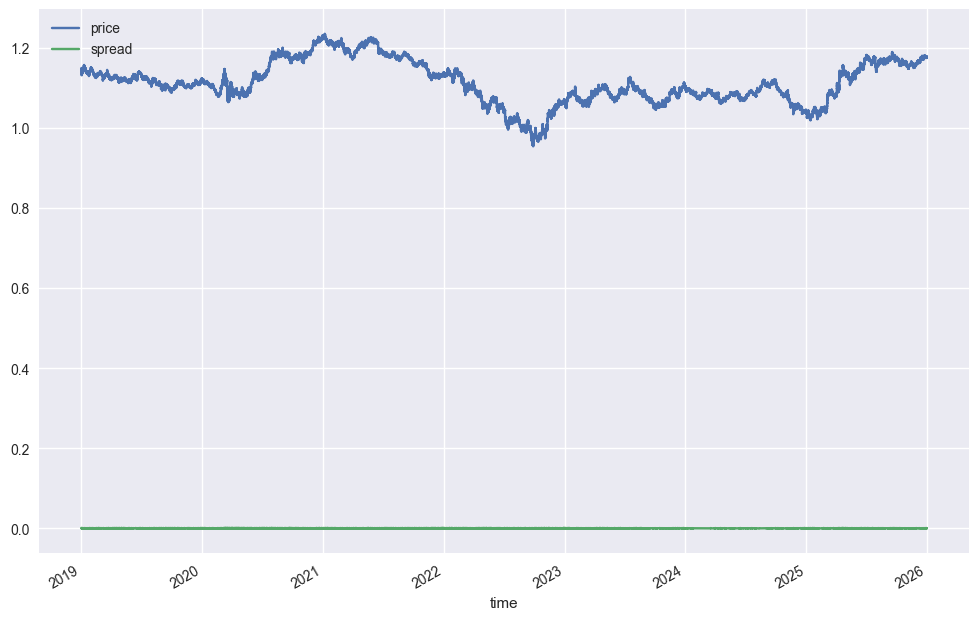

In [7]:
data.plot(figsize = (12, 8))
plt.show()

In [8]:
data["returns"] = np.log(data[symbol] / data[symbol].shift())

In [9]:
data

,price,spread,returns
time,,,
2019-01-01 22:00:00,1.14632,0.00100,NaN
2019-01-01 22:15:00,1.14648,0.00069,0.00014
2019-01-01 22:30:00,1.14637,0.00048,-0.00010
2019-01-01 22:45:00,1.14641,0.00078,0.00003
2019-01-01 23:00:00,1.14660,0.00019,0.00017
...,...,...,...
2025-12-30 22:45:00,1.17466,0.00025,-0.00012
2025-12-30 23:00:00,1.17490,0.00017,0.00020
2025-12-30 23:15:00,1.17476,0.00019,-0.00012


## Adding Label/Features

In [10]:
window = 50

In [11]:
df = data.copy()
df["dir"] = np.where(df["returns"] > 0, 1, 0)
df["sma"] = df[symbol].rolling(window).mean() - df[symbol].rolling(150).mean()
df["boll"] = (df[symbol] - df[symbol].rolling(window).mean()) / df[symbol].rolling(window).std()
df["min"] = df[symbol].rolling(window).min() / df[symbol] - 1
df["max"] = df[symbol].rolling(window).max() / df[symbol] - 1
df["mom"] = df["returns"].rolling(3).mean()
df["vol"] = df["returns"].rolling(window).std()
df.dropna(inplace = True)

In [12]:
df

,price,spread,returns,dir,sma,boll,min,max,mom,vol
time,,,,,,,,,,
2019-01-03 11:15:00,1.13547,0.00014,-0.00017,0,-0.00337,-0.41014,-0.00372,0.00244,-0.00045,0.00063
2019-01-03 11:30:00,1.13498,0.00013,-0.00043,0,-0.00328,-0.76137,-0.00329,0.00287,-0.00055,0.00060
2019-01-03 11:45:00,1.13416,0.00015,-0.00072,0,-0.00320,-1.34227,-0.00257,0.00360,-0.00044,0.00061
2019-01-03 12:00:00,1.13437,0.00014,0.00019,1,-0.00310,-1.23208,-0.00275,0.00341,-0.00032,0.00061
2019-01-03 12:15:00,1.13482,0.00013,0.00040,1,-0.00295,-1.09565,-0.00099,0.00301,-0.00005,0.00054
...,...,...,...,...,...,...,...,...,...,...
2025-12-30 22:45:00,1.17466,0.00025,-0.00012,0,-0.00087,-1.23483,-0.00022,0.00249,-0.00005,0.00027
2025-12-30 23:00:00,1.17490,0.00017,0.00020,1,-0.00090,-0.92675,-0.00043,0.00216,0.00001,0.00027
2025-12-30 23:15:00,1.17476,0.00019,-0.00012,0,-0.00094,-1.07876,-0.00031,0.00228,-0.00001,0.00027


## Adding Feature lags

In [13]:
lags = 5

In [14]:
cols = []
features = ["dir", "sma", "boll", "min", "max", "mom", "vol"]

In [15]:
for f in features:
        for lag in range(1, lags + 1):
            col = "{}_lag_{}".format(f, lag)
            df[col] = df[f].shift(lag)
            cols.append(col)
df.dropna(inplace = True)

In [16]:
df

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,mom_lag_1,mom_lag_2,mom_lag_3,mom_lag_4,mom_lag_5,vol_lag_1,vol_lag_2,vol_lag_3,vol_lag_4,vol_lag_5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,1.13535,0.00012,0.00047,1,-0.00284,-0.71579,-0.00125,0.00255,0.00035,0.00045,...,-0.00005,-0.00032,-0.00044,-0.00055,-0.00045,0.00054,0.00061,0.00061,0.00060,0.00063
2019-01-03 12:45:00,1.13436,0.00012,-0.00087,0,-0.00276,-1.56972,-0.00038,0.00342,-0.00000,0.00046,...,0.00035,-0.00005,-0.00032,-0.00044,-0.00055,0.00045,0.00054,0.00061,0.00061,0.00060
2019-01-03 13:00:00,1.13483,0.00044,0.00041,1,-0.00266,-1.21306,-0.00075,0.00300,0.00000,0.00046,...,-0.00000,0.00035,-0.00005,-0.00032,-0.00044,0.00046,0.00045,0.00054,0.00061,0.00061
2019-01-03 13:15:00,1.13506,0.00021,0.00020,1,-0.00257,-1.06133,-0.00079,0.00280,-0.00009,0.00046,...,0.00000,-0.00000,0.00035,-0.00005,-0.00032,0.00046,0.00046,0.00045,0.00054,0.00061
2019-01-03 13:30:00,1.13574,0.00013,0.00060,1,-0.00248,-0.47358,-0.00139,0.00220,0.00041,0.00046,...,-0.00009,0.00000,-0.00000,0.00035,-0.00005,0.00046,0.00046,0.00046,0.00045,0.00054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 22:45:00,1.17466,0.00025,-0.00012,0,-0.00087,-1.23483,-0.00022,0.00249,-0.00005,0.00027,...,-0.00000,0.00007,0.00009,0.00002,0.00007,0.00027,0.00028,0.00030,0.00030,0.00031
2025-12-30 23:00:00,1.17490,0.00017,0.00020,1,-0.00090,-0.92675,-0.00043,0.00216,0.00001,0.00027,...,-0.00005,-0.00000,0.00007,0.00009,0.00002,0.00027,0.00027,0.00028,0.00030,0.00030
2025-12-30 23:15:00,1.17476,0.00019,-0.00012,0,-0.00094,-1.07876,-0.00031,0.00228,-0.00001,0.00027,...,0.00001,-0.00005,-0.00000,0.00007,0.00009,0.00027,0.00027,0.00027,0.00028,0.00030


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 173999 entries, 2019-01-03 12:30:00 to 2025-12-30 23:45:00
Data columns (total 45 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   price       173999 non-null  float64
 1   spread      173999 non-null  float64
 2   returns     173999 non-null  float64
 3   dir         173999 non-null  int64  
 4   sma         173999 non-null  float64
 5   boll        173999 non-null  float64
 6   min         173999 non-null  float64
 7   max         173999 non-null  float64
 8   mom         173999 non-null  float64
 9   vol         173999 non-null  float64
 10  dir_lag_1   173999 non-null  float64
 11  dir_lag_2   173999 non-null  float64
 12  dir_lag_3   173999 non-null  float64
 13  dir_lag_4   173999 non-null  float64
 14  dir_lag_5   173999 non-null  float64
 15  sma_lag_1   173999 non-null  float64
 16  sma_lag_2   173999 non-null  float64
 17  sma_lag_3   173999 non-null  float64
 18  sma_lag_4 

In [18]:
len(cols)

35

## Splitting into Train / Validation / Test (Year-based)

- **Train:** 2019–2023
- **Validation:** 2024
- **Out-of-sample test:** 2025

In [19]:
len(df)

173999

In [20]:
# Year-based split (no leakage into 2025)
if not isinstance(df.index, pd.DatetimeIndex):
    df = df.copy()
    df.index = pd.to_datetime(df.index)

years = df.index.year
train = df[(years >= 2019) & (years <= 2023)].copy()
val   = df[years == 2024].copy()
test  = df[years == 2025].copy()

print('Train:', train.index.min(), '→', train.index.max(), 'rows=', len(train))
print('Val  :', val.index.min(),   '→', val.index.max(),   'rows=', len(val))
print('Test :', test.index.min(),  '→', test.index.max(),  'rows=', len(test))

if len(val) == 0 or len(test) == 0:
    raise ValueError('Validation (2024) and/or Test (2025) split is empty. Check dataset coverage after feature engineering.')

Train: 2019-01-03 12:30:00 → 2023-12-29 21:45:00 rows= 124274
Val  : 2024-01-01 22:00:00 → 2024-12-31 21:45:00 rows= 24949
Test : 2025-01-01 22:00:00 → 2025-12-30 23:45:00 rows= 24776


In [21]:
train

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,mom_lag_1,mom_lag_2,mom_lag_3,mom_lag_4,mom_lag_5,vol_lag_1,vol_lag_2,vol_lag_3,vol_lag_4,vol_lag_5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,1.13535,0.00012,0.00047,1,-0.00284,-0.71579,-0.00125,0.00255,0.00035,0.00045,...,-0.00005,-0.00032,-0.00044,-0.00055,-0.00045,0.00054,0.00061,0.00061,0.00060,0.00063
2019-01-03 12:45:00,1.13436,0.00012,-0.00087,0,-0.00276,-1.56972,-0.00038,0.00342,-0.00000,0.00046,...,0.00035,-0.00005,-0.00032,-0.00044,-0.00055,0.00045,0.00054,0.00061,0.00061,0.00060
2019-01-03 13:00:00,1.13483,0.00044,0.00041,1,-0.00266,-1.21306,-0.00075,0.00300,0.00000,0.00046,...,-0.00000,0.00035,-0.00005,-0.00032,-0.00044,0.00046,0.00045,0.00054,0.00061,0.00061
2019-01-03 13:15:00,1.13506,0.00021,0.00020,1,-0.00257,-1.06133,-0.00079,0.00280,-0.00009,0.00046,...,0.00000,-0.00000,0.00035,-0.00005,-0.00032,0.00046,0.00046,0.00045,0.00054,0.00061
2019-01-03 13:30:00,1.13574,0.00013,0.00060,1,-0.00248,-0.47358,-0.00139,0.00220,0.00041,0.00046,...,-0.00009,0.00000,-0.00000,0.00035,-0.00005,0.00046,0.00046,0.00046,0.00045,0.00054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 20:45:00,1.10411,0.00016,-0.00018,0,-0.00178,-1.62916,-0.00001,0.00346,-0.00026,0.00059,...,0.00006,0.00015,0.00027,-0.00014,-0.00032,0.00059,0.00061,0.00060,0.00059,0.00060
2023-12-29 21:00:00,1.10358,0.00017,-0.00048,0,-0.00177,-2.02317,0.00000,0.00394,-0.00036,0.00057,...,-0.00026,0.00006,0.00015,0.00027,-0.00014,0.00059,0.00059,0.00061,0.00060,0.00059
2023-12-29 21:15:00,1.10366,0.00015,0.00007,1,-0.00177,-1.83452,-0.00007,0.00387,-0.00020,0.00057,...,-0.00036,-0.00026,0.00006,0.00015,0.00027,0.00057,0.00059,0.00059,0.00061,0.00060


In [22]:
test

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,mom_lag_1,mom_lag_2,mom_lag_3,mom_lag_4,mom_lag_5,vol_lag_1,vol_lag_2,vol_lag_3,vol_lag_4,vol_lag_5
time,,,,,,,,,,,,,,,,,,,,,
2025-01-01 22:00:00,1.03526,0.00087,-0.00007,0,-0.00230,-0.92195,-0.00057,0.00638,-0.00019,0.00044,...,-0.00020,-0.00001,-0.00005,-0.00005,0.00003,0.00045,0.00045,0.00045,0.00047,0.00047
2025-01-01 22:15:00,1.03559,0.00058,0.00032,1,-0.00238,-0.75655,-0.00089,0.00604,-0.00007,0.00044,...,-0.00019,-0.00020,-0.00001,-0.00005,-0.00005,0.00044,0.00045,0.00045,0.00045,0.00047
2025-01-01 22:30:00,1.03575,0.00026,0.00015,1,-0.00246,-0.65839,-0.00104,0.00588,0.00014,0.00044,...,-0.00007,-0.00019,-0.00020,-0.00001,-0.00005,0.00044,0.00044,0.00045,0.00045,0.00045
2025-01-01 22:45:00,1.03568,0.00041,-0.00007,0,-0.00252,-0.65774,-0.00098,0.00595,0.00014,0.00044,...,0.00014,-0.00007,-0.00019,-0.00020,-0.00001,0.00044,0.00044,0.00044,0.00045,0.00045
2025-01-01 23:00:00,1.03539,0.00018,-0.00028,0,-0.00259,-0.75455,-0.00070,0.00623,-0.00006,0.00044,...,0.00014,0.00014,-0.00007,-0.00019,-0.00020,0.00044,0.00044,0.00044,0.00044,0.00045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 22:45:00,1.17466,0.00025,-0.00012,0,-0.00087,-1.23483,-0.00022,0.00249,-0.00005,0.00027,...,-0.00000,0.00007,0.00009,0.00002,0.00007,0.00027,0.00028,0.00030,0.00030,0.00031
2025-12-30 23:00:00,1.17490,0.00017,0.00020,1,-0.00090,-0.92675,-0.00043,0.00216,0.00001,0.00027,...,-0.00005,-0.00000,0.00007,0.00009,0.00002,0.00027,0.00027,0.00028,0.00030,0.00030
2025-12-30 23:15:00,1.17476,0.00019,-0.00012,0,-0.00094,-1.07876,-0.00031,0.00228,-0.00001,0.00027,...,0.00001,-0.00005,-0.00000,0.00007,0.00009,0.00027,0.00027,0.00027,0.00028,0.00030


## Feature Scaling (Standardization)

In [23]:
train[cols]

,dir_lag_1,dir_lag_2,dir_lag_3,dir_lag_4,dir_lag_5,sma_lag_1,sma_lag_2,sma_lag_3,sma_lag_4,sma_lag_5,...,mom_lag_1,mom_lag_2,mom_lag_3,mom_lag_4,mom_lag_5,vol_lag_1,vol_lag_2,vol_lag_3,vol_lag_4,vol_lag_5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,1.00000,1.00000,0.00000,0.00000,0.00000,-0.00295,-0.00310,-0.00320,-0.00328,-0.00337,...,-0.00005,-0.00032,-0.00044,-0.00055,-0.00045,0.00054,0.00061,0.00061,0.00060,0.00063
2019-01-03 12:45:00,1.00000,1.00000,1.00000,0.00000,0.00000,-0.00284,-0.00295,-0.00310,-0.00320,-0.00328,...,0.00035,-0.00005,-0.00032,-0.00044,-0.00055,0.00045,0.00054,0.00061,0.00061,0.00060
2019-01-03 13:00:00,0.00000,1.00000,1.00000,1.00000,0.00000,-0.00276,-0.00284,-0.00295,-0.00310,-0.00320,...,-0.00000,0.00035,-0.00005,-0.00032,-0.00044,0.00046,0.00045,0.00054,0.00061,0.00061
2019-01-03 13:15:00,1.00000,0.00000,1.00000,1.00000,1.00000,-0.00266,-0.00276,-0.00284,-0.00295,-0.00310,...,0.00000,-0.00000,0.00035,-0.00005,-0.00032,0.00046,0.00046,0.00045,0.00054,0.00061
2019-01-03 13:30:00,1.00000,1.00000,0.00000,1.00000,1.00000,-0.00257,-0.00266,-0.00276,-0.00284,-0.00295,...,-0.00009,0.00000,-0.00000,0.00035,-0.00005,0.00046,0.00046,0.00046,0.00045,0.00054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 20:45:00,0.00000,0.00000,1.00000,0.00000,1.00000,-0.00176,-0.00175,-0.00175,-0.00176,-0.00175,...,0.00006,0.00015,0.00027,-0.00014,-0.00032,0.00059,0.00061,0.00060,0.00059,0.00060
2023-12-29 21:00:00,0.00000,0.00000,0.00000,1.00000,0.00000,-0.00178,-0.00176,-0.00175,-0.00175,-0.00176,...,-0.00026,0.00006,0.00015,0.00027,-0.00014,0.00059,0.00059,0.00061,0.00060,0.00059
2023-12-29 21:15:00,0.00000,0.00000,0.00000,0.00000,1.00000,-0.00177,-0.00178,-0.00176,-0.00175,-0.00175,...,-0.00036,-0.00026,0.00006,0.00015,0.00027,0.00057,0.00059,0.00059,0.00061,0.00060


In [24]:
mu, std = train[cols].mean(), train[cols].std()  # train-set parameters for feature standardization

In [25]:
std

dir_lag_1    0.49995
dir_lag_2    0.49995
dir_lag_3    0.49995
dir_lag_4    0.49995
dir_lag_5    0.49995
sma_lag_1    0.00238
sma_lag_2    0.00238
sma_lag_3    0.00238
sma_lag_4    0.00238
sma_lag_5    0.00238
boll_lag_1   1.42372
boll_lag_2   1.42372
boll_lag_3   1.42372
boll_lag_4   1.42371
boll_lag_5   1.42370
min_lag_1    0.00224
min_lag_2    0.00224
min_lag_3    0.00224
min_lag_4    0.00224
min_lag_5    0.00224
max_lag_1    0.00223
max_lag_2    0.00223
max_lag_3    0.00223
max_lag_4    0.00223
max_lag_5    0.00223
mom_lag_1    0.00028
mom_lag_2    0.00028
mom_lag_3    0.00028
mom_lag_4    0.00028
mom_lag_5    0.00028
vol_lag_1    0.00023
vol_lag_2    0.00023
vol_lag_3    0.00023
vol_lag_4    0.00023
vol_lag_5    0.00023
dtype: float64

In [26]:
train_s = (train - mu) / std # standardization of train set features

In [27]:
train_s

,boll,boll_lag_1,boll_lag_2,boll_lag_3,boll_lag_4,boll_lag_5,dir,dir_lag_1,dir_lag_2,dir_lag_3,...,sma_lag_3,sma_lag_4,sma_lag_5,spread,vol,vol_lag_1,vol_lag_2,vol_lag_3,vol_lag_4,vol_lag_5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,NaN,-0.76912,-0.86495,-0.94235,-0.53435,-0.28765,NaN,1.01390,1.01390,-0.98627,...,-1.33653,-1.37214,-1.40710,NaN,NaN,0.42927,0.72204,0.73798,0.71846,0.83245
2019-01-03 12:45:00,NaN,-0.50231,-0.76913,-0.86496,-0.94237,-0.53436,NaN,1.01390,1.01390,1.01392,...,-1.29535,-1.33652,-1.37212,NaN,NaN,0.04806,0.42927,0.72203,0.73798,0.71846
2019-01-03 13:00:00,NaN,-1.10210,-0.50232,-0.76913,-0.86497,-0.94238,NaN,-0.98628,1.01390,1.01392,...,-1.23300,-1.29534,-1.33651,NaN,NaN,0.10785,0.04806,0.42927,0.72203,0.73798
2019-01-03 13:15:00,NaN,-0.85159,-1.10211,-0.50232,-0.76914,-0.86498,NaN,1.01390,-0.98628,1.01392,...,-1.18771,-1.23299,-1.29532,NaN,NaN,0.11829,0.10784,0.04806,0.42927,0.72203
2019-01-03 13:30:00,NaN,-0.74501,-0.85159,-1.10211,-0.50233,-0.76915,NaN,1.01390,1.01390,-0.98627,...,-1.15184,-1.18770,-1.23298,NaN,NaN,0.12144,0.11829,0.10784,0.04806,0.42927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-29 20:45:00,NaN,-1.04484,-0.76939,-0.64627,-1.29381,-1.24703,NaN,-0.98628,-0.98628,1.01392,...,-0.72990,-0.73356,-0.72835,NaN,NaN,0.67318,0.72070,0.71884,0.67187,0.69858
2023-12-29 21:00:00,NaN,-1.14385,-1.04484,-0.76939,-0.64628,-1.29383,NaN,-0.98628,-0.98628,-0.98627,...,-0.72700,-0.72989,-0.73355,NaN,NaN,0.67312,0.67318,0.72070,0.71884,0.67187
2023-12-29 21:15:00,NaN,-1.42059,-1.14385,-1.04485,-0.76941,-0.64629,NaN,-0.98628,-0.98628,-0.98627,...,-0.73256,-0.72699,-0.72989,NaN,NaN,0.55236,0.67312,0.67318,0.72069,0.71883


In [28]:
train_s.describe()

,boll,boll_lag_1,boll_lag_2,boll_lag_3,boll_lag_4,boll_lag_5,dir,dir_lag_1,dir_lag_2,dir_lag_3,...,sma_lag_3,sma_lag_4,sma_lag_5,spread,vol,vol_lag_1,vol_lag_2,vol_lag_3,vol_lag_4,vol_lag_5
count,0.00000,124274.00000,124274.00000,124274.00000,124274.00000,124274.00000,0.00000,124274.00000,124274.00000,124274.00000,...,124274.00000,124274.00000,124274.00000,0.00000,0.00000,124274.00000,124274.00000,124274.00000,124274.00000,124274.00000
mean,NaN,0.00000,-0.00000,-0.00000,-0.00000,-0.00000,NaN,0.00000,-0.00000,0.00000,...,-0.00000,-0.00000,-0.00000,NaN,NaN,-0.00000,0.00000,-0.00000,-0.00000,-0.00000
std,NaN,1.00000,1.00000,1.00000,1.00000,1.00000,NaN,1.00000,1.00000,1.00000,...,1.00000,1.00000,1.00000,NaN,NaN,1.00000,1.00000,1.00000,1.00000,1.00000
min,NaN,-4.44686,-4.44687,-4.44689,-4.44693,-4.44696,NaN,-0.98628,-0.98628,-0.98627,...,-5.05094,-5.05091,-5.05088,NaN,NaN,-1.56640,-1.56640,-1.56640,-1.56640,-1.56640
25%,NaN,-0.73615,-0.73615,-0.73615,-0.73612,-0.73612,NaN,-0.98628,-0.98628,-0.98627,...,-0.57646,-0.57646,-0.57645,NaN,NaN,-0.67324,-0.67324,-0.67324,-0.67324,-0.67324
50%,NaN,0.00124,0.00124,0.00124,0.00123,0.00122,NaN,-0.98628,-0.98628,-0.98627,...,-0.00826,-0.00825,-0.00825,NaN,NaN,-0.23116,-0.23116,-0.23116,-0.23117,-0.23117
75%,NaN,0.74520,0.74520,0.74520,0.74520,0.74520,NaN,1.01390,1.01390,1.01392,...,0.56274,0.56274,0.56274,NaN,NaN,0.39248,0.39248,0.39248,0.39247,0.39247
max,NaN,4.38644,4.38645,4.38646,4.38648,4.38650,NaN,1.01390,1.01390,1.01392,...,4.97205,4.97203,4.97201,NaN,NaN,8.83990,8.83989,8.83988,8.83988,8.83987


In [29]:
# Standardize validation set with TRAIN parameters
val_s = (val - mu) / std

## Creating and Fitting the DNN Model

In [30]:
from DNNModel import *

In [31]:
# fitting a DNN model with 3 Hidden Layers (50 nodes each) and dropout regularization

# Keras/TensorFlow sanity: model.fit will fail if TF eager execution is disabled
import tensorflow as tf
try:
    if not tf.executing_eagerly():
        # Try to enable eager (may require a fresh kernel to take effect)
        tf.compat.v1.enable_eager_execution()
except Exception as _e:
    print('Warning: could not enable eager execution:', _e)
    print('If you still get numpy()/eager errors, restart the kernel and rerun from the top.')

# Optional: force eager for tf.functions (slower but avoids graph->numpy issues)
tf.config.run_functions_eagerly(True)

# Important with the provided DNNModel.py: use a fresh optimizer per model
tf.keras.backend.clear_session()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

set_seeds(100)
model = create_model(hl = 3, hu = 50, dropout = True, input_dim = len(cols), optimizer = optimizer)
model.fit(x = train_s[cols], y = train["dir"], epochs = 50, verbose = False,
          validation_data = (val_s[cols], val["dir"]), shuffle = False, class_weight = cw(train))

d:\anaconda3\envs\mlops_test\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\anaconda3\envs\mlops_test\lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(
d:\anaconda3\envs\mlops_test\lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `

KeyboardInterrupt: 

In [ ]:
model.evaluate(train_s[cols], train["dir"]) # evaluate the fit on the train set

In [ ]:
pred = model.predict(train_s[cols]) # prediction (probabilities)
pred

In [ ]:
plt.hist(pred, bins = 50)
plt.show()

## Out-Sample Prediction and Forward Testing

In [ ]:
test

In [ ]:
test_s = (test - mu) / std # standardization of test set features (with train set parameters!!!)

In [ ]:
model.evaluate(test_s[cols], test["dir"])

In [ ]:
pred = model.predict(test_s[cols])
pred

In [ ]:
plt.hist(pred, bins = 50)

In [ ]:
test["proba"] = model.predict(test_s[cols])

In [ ]:
test["position"] = np.where(test.proba < 0.47, -1, np.nan) # 1. short where proba < 0.47

In [ ]:
test["position"] = np.where(test.proba > 0.53, 1, test.position) # 2. long where proba > 0.53

In [ ]:
test.index = test.index.tz_localize("UTC")
test["NYTime"] = test.index.tz_convert("America/New_York")
test["hour"] = test.NYTime.dt.hour

In [ ]:
test["position"] = np.where(~test.hour.between(2, 12), 0, test.position) # 3. neutral in non-busy hours

In [ ]:
test["position"] = test.position.ffill().fillna(0) # 4. in all other cases: hold position

In [ ]:
test.position.value_counts(dropna = False)

In [ ]:
test["strategy"] = test["position"] * test["returns"]

In [ ]:
test["creturns"] = test["returns"].cumsum().apply(np.exp)
test["cstrategy"] = test["strategy"].cumsum().apply(np.exp)

In [ ]:
test[["creturns", "cstrategy"]].plot(figsize = (12, 8))
plt.show()

In [ ]:
ptc = 0.000059

In [ ]:
test["trades"] = test.position.diff().abs()

In [ ]:
test.trades.value_counts()

In [ ]:
test["strategy_net"] = test.strategy - test.trades * ptc

In [ ]:
test["cstrategy_net"] = test["strategy_net"].cumsum().apply(np.exp)

In [ ]:
test[["creturns", "cstrategy", "cstrategy_net"]].plot(figsize = (12, 8))
plt.show()

## Saving Model and Parameters

In [ ]:
model

In [ ]:
mu

In [ ]:
std

In [ ]:
model.save("DNN_model")

In [ ]:
import pickle

In [ ]:
params = {"mu":mu, "std":std}

In [ ]:
params

In [ ]:
pickle.dump(params, open("params.pkl", "wb"))

## Implementation

In [ ]:
import pandas as pd
import numpy as np
import tpqoa
from datetime import datetime, timezone, timedelta # timezone added
import time
import warnings
warnings.filterwarnings('ignore')

__Loading Model and Parameters__

In [ ]:
# Loading the model
import keras
model = keras.models.load_model("DNN_model")

In [ ]:
model

In [ ]:
# Loading mu and std
import pickle
params = pickle.load(open("params.pkl", "rb"))
mu = params["mu"]
std = params["std"]

In [ ]:
mu

In [ ]:
std